[data] loading cifar10 (train=True, download=True) from /home/owais/machine unlearning/ebm_unlearning/data
Files already downloaded and verified


/home/owais/machine unlearning/ebm_unlearning/src/training/pretrain.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(checkpoint_path, map_location=devi

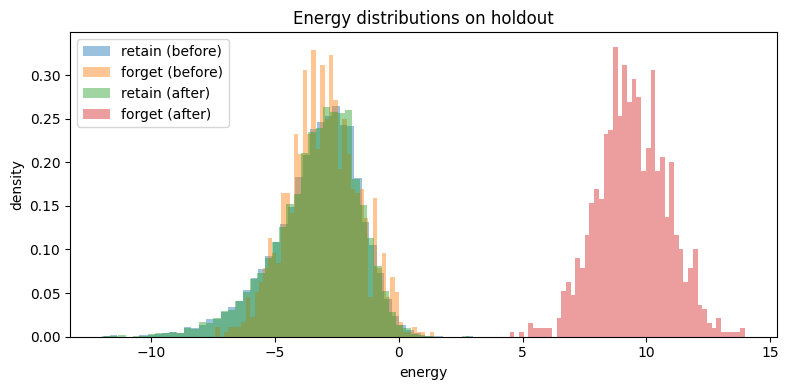

Mean energies:
 retain before/after: -3.3056180477142334 -3.3079206943511963
 forget before/after: -3.0267534255981445 9.437187194824219
 gap after (forget-retain): 12.745107650756836


: 

In [ ]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import torch
import yaml
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader


def find_project_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(6):
        if (p / "configs" / "config.yaml").exists():
            return p
        p = p.parent
    raise FileNotFoundError("Could not find configs/config.yaml")


ROOT = find_project_root()
sys.path.insert(0, str(ROOT.parent))

from ebm_unlearning.src.data.dataset import DatasetSpec, load_dataset
from ebm_unlearning.src.data.split import ForgetSpec, RetainSpec, split_forget_retain, train_holdout_split
from ebm_unlearning.src.evaluation.metrics import collect_energies
from ebm_unlearning.src.models.ebm import EnergyModel
from ebm_unlearning.src.training.pretrain import load_pretrained
from ebm_unlearning.src.utils.seed import set_seed

with open(ROOT / "configs" / "config.yaml", "r") as f:
    cfg = yaml.safe_load(f)

set_seed(int(cfg["seed"]))

device = torch.device(cfg.get("device", "cpu"))

# Build holdout loaders
spec = DatasetSpec(name=cfg["data"]["dataset"], data_dir=str(ROOT / cfg["data"]["data_dir"]), train=True, download=True)
dset = load_dataset(spec)

forget_spec = ForgetSpec(mode=cfg["data"]["forget"]["mode"], class_label=cfg["data"]["forget"]["class_label"])
retain_spec = RetainSpec(mode=cfg["data"]["retain"]["mode"])
forget_all, retain_all = split_forget_retain(dset, forget_spec, retain_spec)

holdout_fraction = float(cfg["evaluation"]["holdout_fraction"])
_, forget_holdout = train_holdout_split(forget_all, holdout_fraction, seed=int(cfg["seed"]))
_, retain_holdout = train_holdout_split(retain_all, holdout_fraction, seed=int(cfg["seed"]) + 1)

batch_size = int(cfg["data"]["batch_size"])
num_workers = int(cfg["data"]["num_workers"])
forget_holdout_loader = DataLoader(forget_holdout, batch_size=batch_size, shuffle=False, num_workers=num_workers)
retain_holdout_loader = DataLoader(retain_holdout, batch_size=batch_size, shuffle=False, num_workers=num_workers)

# Load models
E0 = EnergyModel(
    in_channels=int(cfg["model"]["in_channels"]),
    hidden_dim=int(cfg["model"]["hidden_dim"]),
    num_classes=int(cfg["model"].get("num_classes", 10)),
    embed_dim=int(cfg["model"].get("embed_dim", 128)),
    backbone=str(cfg["model"].get("backbone", "conv")),
    finetune_stages=int(cfg["model"].get("finetune_stages", 1)),
    imagenet_pretrained=bool(cfg["model"].get("imagenet_pretrained", True)),
)
E0 = load_pretrained(E0, str(ROOT / cfg["pretrain"]["checkpoint_path"]), device=device)

E = EnergyModel(
    in_channels=int(cfg["model"]["in_channels"]),
    hidden_dim=int(cfg["model"]["hidden_dim"]),
    num_classes=int(cfg["model"].get("num_classes", 10)),
    embed_dim=int(cfg["model"].get("embed_dim", 128)),
    backbone=str(cfg["model"].get("backbone", "conv")),
    finetune_stages=int(cfg["model"].get("finetune_stages", 1)),
    imagenet_pretrained=bool(cfg["model"].get("imagenet_pretrained", True)),
)
E = load_pretrained(E, str(ROOT / cfg["unlearning"]["checkpoint_path"]), device=device)

# Plot energy distributions (holdout)
ef0 = collect_energies(E0, forget_holdout_loader, device=device)
er0 = collect_energies(E0, retain_holdout_loader, device=device)
ef = collect_energies(E, forget_holdout_loader, device=device)
er = collect_energies(E, retain_holdout_loader, device=device)

plt.figure(figsize=(8, 4))
bins = 50
plt.hist(er0, bins=bins, alpha=0.45, label="retain (before)", density=True)
plt.hist(ef0, bins=bins, alpha=0.45, label="forget (before)", density=True)
plt.hist(er, bins=bins, alpha=0.45, label="retain (after)", density=True)
plt.hist(ef, bins=bins, alpha=0.45, label="forget (after)", density=True)
plt.title("Energy distributions on holdout")
plt.xlabel("energy")
plt.ylabel("density")
plt.legend()
plt.tight_layout()
plt.show()

print("Mean energies:")
print(" retain before/after:", float(np.mean(er0)), float(np.mean(er)))
print(" forget before/after:", float(np.mean(ef0)), float(np.mean(ef)))
print(" gap after (forget-retain):", float(np.mean(ef) - np.mean(er)))

